<a href="https://colab.research.google.com/github/r3mo-usd/AAI-500-02-final-project-Sahana-Javier/blob/feature%2Fdata-cleaning-eda/src/javier_da.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Config

**Introduction**

When a customer cancels their service, it is called **customer churn**. Customers often do not leave after a single bad experience. They usually cancel after repeated disappointments, such as billing problems or poor service. Once they leave, the company loses that customer's ongoing revenue and has to spend money to replace them. Attracting a new customer is more expensive than keeping an existing one.

This project uses the Telco Customer Churn dataset, a publicly available sample dataset originally released by IBM. It contains information on 7,043 customers, including demographics, account details (contract type, tenure, payment method), services subscribed to, and monthly and total charges. The target variable is Churn (Yes/No), and 26.5% of customers in the dataset have churned.

We want to identify the reasons behind customer churn and understand which factors influence it, so the company can improve customer retention. If we can find the warning signs early, the company can act before the customer decides to leave. To do this, we first clean and explore the data to see which characteristics are related to churn. We then build a logistic regression model to test and measure those relationships.

## Import Libraries

In [1]:
# libraries used in this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import ttest_ind

### **Load the data**

In [2]:
# load the dataset from the shared GitHub repo (main branch)
url = 'https://raw.githubusercontent.com/r3mo-usd/AAI-500-02-final-project-Sahana-Javier/main/data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
telco = pd.read_csv(url)

In [3]:
# first 5 observations
print(telco.head(5))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## **Check variable types**

In [4]:
# dimensions: 7043 rows, 21 columns
print(telco.shape)

# non-missing counts and data type for each variable
# TotalCharges shows up as object (text) instead of a number
print(telco.info())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

TotalCharges is stored as text, so it must be converted to numeric before analysis.

### **Convert TotalCharges**

In [5]:
# TotalCharges is stored as text; convert to numeric
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')

# count the missing values created by the conversion
telco['TotalCharges'].isna().sum()

np.int64(11)

**Inspect the 11 blanks**

In [6]:
# check which customers have missing TotalCharges
telco.loc[telco['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


**Fill the blanks**

In [7]:
# fill missing TotalCharges with 0 (new customers have not been charged yet)
telco['TotalCharges'] = telco['TotalCharges'].fillna(0)

# check that no missing values are left (should show 0)
telco['TotalCharges'].isna().sum()

np.int64(0)

We set these values to 0 instead of dropping the rows, so all 7,043 customers stay in the sample.

**Drop customerID**

In [8]:
# drop customerID because it is just an ID number for each customer
telco = telco.drop(['customerID'], axis=1)
telco.shape

(7043, 20)

### Recoding SeniorCitizen

In [9]:
#change SeniorCitizen from 1/0 to Yes/No so it matches the other columnsprint
(telco["SeniorCitizen"].value_counts())
telco["SeniorCitizen"] = telco["SeniorCitizen"].replace({1: "Yes", 0: "No"})

# check the new values (show only No and Yes)
print(telco["SeniorCitizen"].value_counts())

SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


In [10]:
# check if "No internet service" only shows up for customers with no internet
pd.crosstab(telco["InternetService"], telco["TechSupport"])

TechSupport,No,No internet service,Yes
InternetService,,,
DSL,1243,0,1178
Fiber optic,2230,0,866
No,0,1526,0


The table shows that 'No internet service' appears only for the 1,526 customers whose InternetService is 'No'. Since InternetService already records this, we collapsed it into 'No' to avoid repeating the same information.

### Simplifying the 'No Service'

In [11]:
# these six columns have "No internet service" as a third option
service_columns = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                    "TechSupport", "StreamingTV", "StreamingMovies"]

for col in service_columns:
    telco[col] = telco[col].replace({"No internet service": "No"})

# do the same for MultipleLines, where "No phone service" becomes "No"
telco["MultipleLines"] = telco["MultipleLines"].replace({"No phone service": "No"})

# check that only Yes and No are left in each column
for col in service_columns + ["MultipleLines"]:
    print(telco[col].value_counts())
    print()


OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64

OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64

DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64

TechSupport
No     4999
Yes    2044
Name: count, dtype: int64

StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64

StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64

MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64



OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, and StreamingMovies each had a third value, "No internet service," which only appears for customers with no internet. InternetService already shows this, so we changed it to "No" MultipleLines had the same issue with "No phone service," which we also changed to "No"

In [12]:
# final check: 7043 rows, 20 columns, no missing values, TotalCharges is float64
telco.info()
telco.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


(7043, 20)

After cleaning, the dataset has 7,043 rows and 20 columns with no missing values. TotalCharges is numeric, customerID was removed, SeniorCitizen is now Yes/No, and the "No internet service" and "No phone service" values were changed to "No".

In [13]:
# save the cleaned dataset for modeling
telco.to_csv("telco_cleaned.csv", index=False)

In [14]:
#from google.colab import files
#files.download("telco_cleaned.csv")

## Exploratory Data Analysis

### Descriptive statistics

In [15]:
# summary statistics for tenure, MonthlyCharges, and TotalCharges
print(telco.describe())

            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


### Tenure histogram

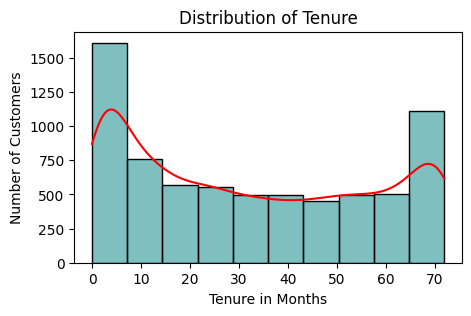

In [16]:
# plot a histogram of tenure with a curve on top
plt.figure(figsize=(5,3))
ax = sns.histplot(telco["tenure"], bins=10, color = "teal", kde=True)

# change the curve to red
ax.lines[0].set_color("red")

# add the labels and title
plt.xlabel("Tenure in Months")
plt.ylabel("Number of Customers")
plt.title("Distribution of Tenure")
plt.show()

Most customers are either new, with less than a year, or have stayed for about 6 years. Fewer customers are in the middle.

### MonthlyCharges histogram

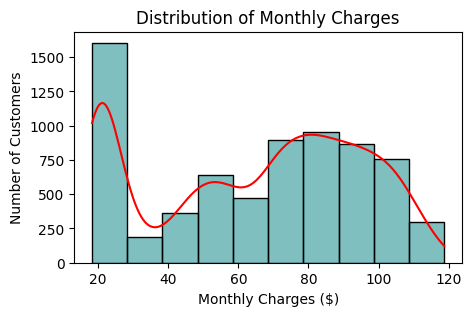

In [17]:
plt.figure(figsize=(5,3))
ax = sns.histplot(telco["MonthlyCharges"], bins=10, color = "teal", kde=True)
ax.lines[0].set_color("red")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")
plt.show()

A big group of customers pays about $20 a month. Most of the others pay between \$70 and \$100.

### TotalCharges histogram

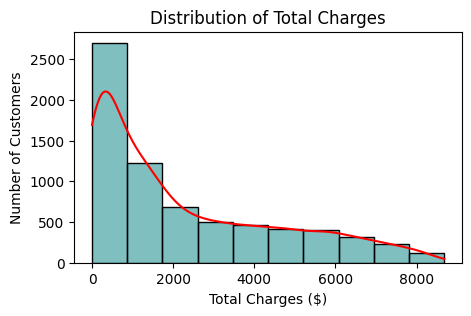

In [18]:
plt.figure(figsize=(5, 3))
ax = sns.histplot(telco["TotalCharges"], bins=10, color = "teal", kde=True)
ax.lines[0].set_color("red")
plt.xlabel("Total Charges ($)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Total Charges")
plt.show()

Most customers have paid under \$900 in total. Only a few have paid more than \$7,000.

#### Churn Rate by Contract Type

In [19]:
pd.crosstab(telco["Contract"],telco["Churn"], normalize = "index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


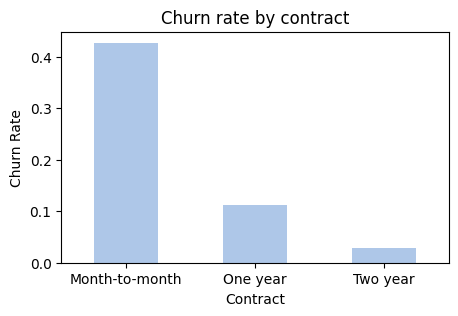

In [20]:
plt.figure(figsize=(5,3))
pd.crosstab(telco["Contract"],telco["Churn"],normalize="index")["Yes"].plot(kind="bar", color="#AEC7E8")
plt.xticks(rotation=0)
plt.ylabel("Churn Rate")
plt.xlabel("Contract")
plt.title("Churn rate by contract")
plt.show()

Month-to-month customers churn the most, at about 43%. One-year contracts churn at about 11%, and two-year contracts at about 3%. Customers on longer contracts are much less likely to leave.

#### Churn Rate by Internet Service

In [21]:
pd.crosstab(telco["InternetService"],telco["Churn"], normalize = "index")

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


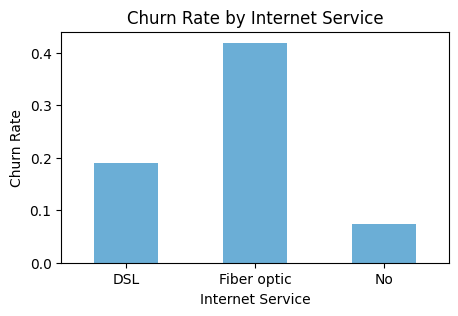

In [22]:
plt.figure(figsize=(5,3))
pd.crosstab(telco["InternetService"],telco["Churn"],normalize="index")["Yes"].plot(kind="bar",color="#6BAED6")
plt.xticks(rotation=0)
plt.ylabel("Churn Rate")
plt.xlabel("Internet Service")
plt.title("Churn Rate by Internet Service")
plt.show()

Fiber optic customers churn the most. 1,297 of 3,096 Fiber optic customers left, which is about 42%. DSL customers churn at about 19%, and customers with no internet service churn at about 7%.

#### Churn Rate by Payment Method

In [23]:
pd.crosstab(telco["PaymentMethod"],telco["Churn"], normalize = "index")

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


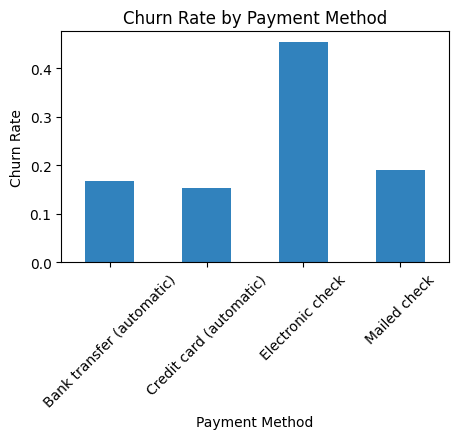

In [24]:
plt.figure(figsize=(5,3))
pd.crosstab(telco["PaymentMethod"],telco["Churn"],normalize="index")["Yes"].plot(kind="bar",color="#3182BD")
plt.xticks(rotation=45)
plt.ylabel("Churn Rate")
plt.xlabel("Payment Method")
plt.title("Churn Rate by Payment Method")
plt.show()

Electronic check has the highest churn rate, at about 45%. The other three payment methods are all between 15% and 19%

#### Churn Rate by Tech Support

In [25]:
pd.crosstab(telco["TechSupport"],telco["Churn"], normalize = "index")

Churn,No,Yes
TechSupport,,
No,0.688138,0.311862
Yes,0.848337,0.151663


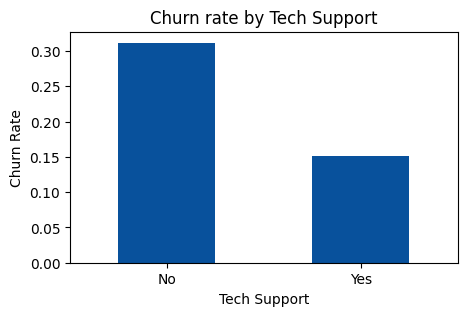

In [26]:
plt.figure(figsize=(5,3))
pd.crosstab(telco["TechSupport"],telco["Churn"],normalize="index")["Yes"].plot(kind="bar",color="#08519C")
plt.xticks(rotation=0)
plt.ylabel("Churn Rate")
plt.xlabel("Tech Support")
plt.title("Churn rate by Tech Support")
plt.show()

Customers without tech support churn more, at about 31%, than customers with tech support, at about 15%. The 'No' group includes customers with no internet service, who rarely churn, so the real gap is probably larger.

#### Creating Tenure Groups

In [27]:
# group tenure into five ranges (include_lowest=True keeps tenure = 0 in 0-12)
telco["tenure_bins"] = pd.cut(telco["tenure"], bins=[0, 12, 24, 48, 60, 72],
                                 labels=["0-12", "12-24", "24-48", "48-60", "60-72"], include_lowest=True)

In [28]:
# every customer should have a group
telco["tenure_bins"].isna().sum()

# number of customers in each group
telco["tenure_bins"].value_counts()

,count
tenure_bins,
0-12,2186
24-48,1594
60-72,1407
12-24,1024
48-60,832


#### Churn Rate by Tenure Group

In [29]:
pd.crosstab(telco["tenure_bins"], telco["Churn"], normalize="index")

Churn,No,Yes
tenure_bins,,
0-12,0.525618,0.474382
12-24,0.712891,0.287109
24-48,0.796110,0.203890
48-60,0.855769,0.144231
60-72,0.933902,0.066098


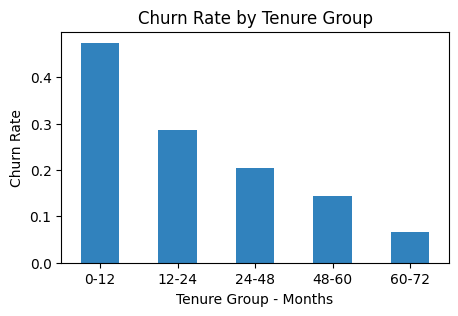

In [30]:
plt.figure(figsize=(5, 3))
pd.crosstab(telco["tenure_bins"], telco["Churn"], normalize="index")["Yes"].plot(kind="bar", color="#3182BD")
plt.xticks(rotation=0)
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group - Months")
plt.title("Churn Rate by Tenure Group")
plt.show()

### Chi-Square Tests: Categorical Variables vs. Churn

We use chi-square tests to check whether each categorical variable is related to churn.

#### Contract and Churn

In [31]:
contract_table = pd.crosstab(telco["Contract"], telco["Churn"])
contract_table

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [32]:
import statsmodels.api as sm
table_contract = sm.stats.Table(contract_table)
result_contract = table_contract.test_nominal_association()
print("chi-square test value:", round(result_contract.statistic, 2))
print("df:", result_contract.df)
print("p-value:", round(result_contract.pvalue, 4))

chi-square test value: 1184.6
df: 2
p-value: 0.0


The chi-square test shows that Contract is significantly associated with churn (chi-square = 1184.60, df = 2, p < 0.001)

#### Internet Service and Churn

In [33]:
internetservice_table = pd.crosstab(telco["InternetService"],telco["Churn"])
internetservice_table

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [34]:
table_internet = sm.stats.Table(internetservice_table)
result_internet = table_internet.test_nominal_association()
print("chi-square test value:", round(result_internet.statistic, 2))
print("df:", result_internet.df)
print("p-value:", round(result_internet.pvalue, 4))

chi-square test value: 732.31
df: 2
p-value: 0.0


#### Payment Method and Churn




In [35]:
paymentmethod_table = pd.crosstab(telco["PaymentMethod"],telco["Churn"])
paymentmethod_table

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [36]:
table_payment = sm.stats.Table(paymentmethod_table)
result_payment = table_payment.test_nominal_association()
print("chi-square test value:", round(result_payment.statistic, 2))
print("df:", result_payment.df)
print("p-value:", round(result_payment.pvalue, 4))

chi-square test value: 648.14
df: 3
p-value: 0.0


#### Tech Support and Churn

In [37]:
techsupport_table = pd.crosstab(telco["TechSupport"], telco["Churn"])
techsupport_table

Churn,No,Yes
TechSupport,,
No,3440,1559
Yes,1734,310


In [38]:
table_techsupport = sm.stats.Table(techsupport_table)
result_techsupport = table_techsupport.test_nominal_association()
print("chi-square test value:", round(result_techsupport.statistic, 2))
print("df:", result_techsupport.df)
print("p-value:", round(result_techsupport.pvalue, 4))

chi-square test value: 190.99
df: 1
p-value: 0.0


 ### t-Tests: Numeric Variables vs. Churn

#### Tenure and Churn

In [39]:
# split tenure into two groups: customers who churned and customers who stayed
churned_customers = telco.loc[telco["Churn"] == "Yes", "tenure"]
stayed_customers = telco.loc[telco["Churn"] == "No", "tenure"]
# average tenure of each group
print("Average tenure-churned:", round(churned_customers.mean(), 2))
print("Average tenure-stayed:", round(stayed_customers.mean(), 2))

Average tenure-churned: 17.98
Average tenure-stayed: 37.57


In [40]:
# run a t-test to check if the difference in average tenure is statistically significant
t_stats, p_value = ttest_ind(churned_customers, stayed_customers, equal_var=False)

print("t-statistic: {:.3f}".format(t_stats))
print("p-value: {:.3e}".format(p_value))

t-statistic: -34.824
p-value: 1.195e-232


Customers who churned had an average tenure of about 18 months. Customers who stayed had an average tenure of about 38 months. The t-test shows this difference is statistically significant (t = -34.82, p < 0.001). This means customers who leave usually do so early, within their first year or two.

#### Monthly Charges and Churn

In [41]:
# split monthy charges into two groups: customers who churned and customers who stayed
churned_monthlycustomers = telco.loc[telco["Churn"] == "Yes", "MonthlyCharges"]
stayed_monthlycustomers = telco.loc[telco["Churn"] == "No", "MonthlyCharges"]

print("Average monthly charges-churned:", round(churned_monthlycustomers.mean(), 2))
print("Average monthly charges-stayed:", round(stayed_monthlycustomers.mean(), 2))

Average monthly charges-churned: 74.44
Average monthly charges-stayed: 61.27


In [42]:
t_stats, p_value = ttest_ind(churned_monthlycustomers, stayed_monthlycustomers, equal_var=False)
print("t-statistic: {:.3f}".format(t_stats))
print("p-value: {:.3e}".format(p_value))

t-statistic: 18.408
p-value: 8.592e-73


Customers who churned paid more per month on average (about \$74) than customers who stayed (about \$61). The t-test shows this difference is statistically significant (t = 18.41, p < 0.001). This means customers with higher monthly charges are more likely to leave.

#### Total Charges and Churn

In [43]:
# split TotalCharges into two groups: customers who churned and customers who stayed
churned_total = telco.loc[telco["Churn"] == "Yes", "TotalCharges"]
stayed_total = telco.loc[telco["Churn"] == "No", "TotalCharges"]

# average TotalCharges of each group
print("Average TotalCharges-churned:", round(churned_total.mean(), 2))
print("Average TotalCharges-stayed:", round(stayed_total.mean(), 2))

Average TotalCharges-churned: 1531.8
Average TotalCharges-stayed: 2549.91


In [44]:
# t-test to compare average TotalCharges of churned and stayed customers
t_total, p_total = ttest_ind(churned_total, stayed_total, equal_var=False)

print("t-statistic: {:.3f}".format(t_total))
print("p-value: {:.3e}".format(p_total))

t-statistic: -18.707
p-value: 5.903e-75


Customers who churned had lower total charges on average (about \$1,532) than customers who stayed (about \$2,550). The t-test shows this difference is statistically significant (t = -18.71, p < 0.001). Churned customers leave early, so they pay for fewer months.

### Correlation between tenure, MonthlyCharges, and TotalCharges

In [45]:
# correlation between the three numeric variables
telco[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


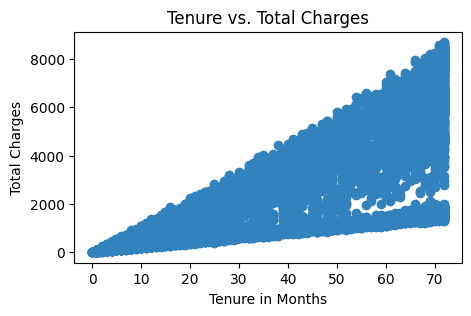

In [46]:
plt.figure(figsize=(5, 3))
plt.scatter(telco["tenure"], telco["TotalCharges"], color="#3182BD")
plt.xlabel("Tenure in Months")
plt.ylabel("Total Charges")
plt.title("Tenure vs. Total Charges")
plt.show()

In the EDA, we found that Contract, Internet Service, Payment Method, and Tech Support are all significantly related to churn, with p < 0.001. Tenure, Monthly Charges, and Total Charges also differ significantly between customers who churned and customers who stayed, with p < 0.001.

Churn is highest for month-to-month contracts at about 43%, fiber optic internet at about 42%, electronic check payments at about 45%, customers without tech support at about 31%, and new customers in their first 12 months at about 47%.

Tenure and Total Charges are strongly correlated, with r = 0.83, so they carry similar information. This could cause problems in the model, so it should be checked.